# Penguji Model — EfficientNet-B0 (triplet v4)

Notebook mandiri untuk menguji apakah model verifikasi tanda tangan **bekerja atau tidak**, tanpa web server.

**Alur:** load model → tentukan gambar TTD **asli** (acuan) → uji gambar → keluar skor kemiripan (cosine) + verdict.

Metriknya sama persis dengan jalur web `/api/verify`: **mean cosine similarity** terhadap acuan, verdict `genuine` jika `>=` threshold.

> Jalankan sel dari atas ke bawah. Model & preprocessing sudah termasuk perbaikan `_load_white_bg` (PNG canvas opaque).

## 1. Import & konfigurasi

In [1]:
import os, glob
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm

# --- Cari checkpoint yang kamu taruh di ProjectAI ---
CKPT_CANDIDATES = [
    'EfficientNet-B0-head-ft.pth', 'EfficientNet-B0-triplet-v4.pth',
    os.path.join('..', 'EfficientNet-B0-head-ft.pth', 'EfficientNet-B0-triplet-v4.pth'),
]
CKPT_PATH = next((p for p in CKPT_CANDIDATES if os.path.exists(p)), None)
if CKPT_PATH is None:
    hits = glob.glob('EfficientNet*.pth') + glob.glob('*.pth') + glob.glob(os.path.join('..','*.pth'))
    CKPT_PATH = hits[0] if hits else None
assert CKPT_PATH and os.path.exists(CKPT_PATH), 'Checkpoint .pth tidak ditemukan — set CKPT_PATH manual.'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
print('Checkpoint :', CKPT_PATH)
print('Device     :', DEVICE)

Checkpoint : EfficientNet-B0-triplet-v4.pth
Device     : cuda


## 2. Preprocessing (identik dengan server, sudah diperbaiki)

In [2]:
def _load_white_bg(path):
    """Buka gambar, ratakan transparansi ke latar PUTIH. Hanya flatten berbasis-alpha
    kalau MEMANG ada piksel transparan; PNG opaque (alpha=255 semua, spt export canvas)
    dipakai apa adanya supaya tidak jadi kotak hitam."""
    img = Image.open(path)
    if img.mode in ('RGBA', 'LA') or (img.mode == 'P' and 'transparency' in img.info):
        img = img.convert('RGBA')
        alpha = img.getchannel('A')
        if alpha.getextrema()[0] < 255:
            black = Image.new('RGBA', img.size, (0, 0, 0, 255))
            transp = Image.new('RGBA', img.size, (255, 255, 255, 0))
            img = Image.composite(black, transp, alpha)
            bg = Image.new('RGBA', img.size, (255, 255, 255, 255))
            img = Image.alpha_composite(bg, img)
    return img.convert('RGB')


def autocrop_and_pad(img, pad_frac=0.08, ink_thresh=245, size=IMG_SIZE):
    gray = np.array(img.convert('L'))
    mask = gray < ink_thresh
    if mask.sum() == 0:
        cropped = img.convert('L')
    else:
        ys, xs = np.where(mask)
        y0, y1 = int(ys.min()), int(ys.max())
        x0, x1 = int(xs.min()), int(xs.max())
        h, w = gray.shape
        pad_y = max(2, int((y1 - y0 + 1) * pad_frac))
        pad_x = max(2, int((x1 - x0 + 1) * pad_frac))
        y0, y1 = max(0, y0 - pad_y), min(h - 1, y1 + pad_y)
        x0, x1 = max(0, x0 - pad_x), min(w - 1, x1 + pad_x)
        cropped = img.convert('L').crop((x0, y0, x1 + 1, y1 + 1))
    cw, ch = cropped.size
    side = max(cw, ch)
    canvas = Image.new('L', (side, side), 255)
    canvas.paste(cropped, ((side - cw) // 2, (side - ch) // 2))
    return canvas.resize((size, size), Image.BILINEAR)


_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def preprocess(path, size=IMG_SIZE):
    img = _load_white_bg(path)
    img = autocrop_and_pad(img, size=size).convert('RGB')
    arr = np.array(img, dtype=np.float32) / 255.0
    t = torch.from_numpy(arr).permute(2, 0, 1)
    return (t - _MEAN) / _STD

## 3. Arsitektur model + load bobot

Head-nya: `Flatten → Linear(1280,512) → BN → ReLU → Dropout → Linear(512,512) → BN`, output di-`L2 normalize`. `embedding_dim` & `threshold` dibaca langsung dari checkpoint.

In [3]:
class EfficientNetEmbedder(nn.Module):
    def __init__(self, embedding_dim=512, dropout=0.3):
        super().__init__()
        effnet = tvm.efficientnet_b0(weights=None)
        self.backbone = nn.Sequential(effnet.features)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = F.adaptive_avg_pool2d(x, 1)
        x = self.head(x)
        return F.normalize(x, p=2, dim=1)


ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
state = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
EMB_DIM = int(ckpt.get('embedding_dim', 512)) if isinstance(ckpt, dict) else 512
THRESHOLD = float(ckpt.get('threshold', 0.96)) if isinstance(ckpt, dict) else 0.96

model = EfficientNetEmbedder(embedding_dim=EMB_DIM).to(DEVICE)
model.load_state_dict(state, strict=True)
model.eval()
print(f'Model loaded. embedding_dim={EMB_DIM}, threshold bawaan={THRESHOLD}')

Model loaded. embedding_dim=512, threshold bawaan=0.9600000000000002


## 4. Fungsi bantu: embed, verifikasi, tampilkan

In [4]:
@torch.no_grad()
def embed(path):
    """Gambar -> vektor embedding L2-normalized (numpy)."""
    t = preprocess(path).unsqueeze(0).to(DEVICE)
    return model(t).cpu().numpy()[0]


def embed_many(paths):
    return np.stack([embed(p) for p in paths]) if paths else np.zeros((0, EMB_DIM), np.float32)


def verify(test_path, ref_embs, threshold=None):
    thr = THRESHOLD if threshold is None else threshold
    te = embed(test_path)
    sims = ref_embs @ te                 # cosine (vektor sudah L2-normalized)
    mean_s, max_s, min_s = float(sims.mean()), float(sims.max()), float(sims.min())
    verdict = 'GENUINE (asli)' if mean_s >= thr else 'FORGED (palsu)'
    return {'verdict': verdict, 'mean_sim': mean_s, 'max_sim': max_s,
            'min_sim': min_s, 'threshold': thr, 'num_refs': int(ref_embs.shape[0])}


def show(path, title=''):
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(3, 3)); plt.imshow(Image.open(path).convert('RGB'))
        plt.axis('off'); plt.title(title); plt.show(); return
    except Exception:
        pass
    try:
        from IPython.display import display
        print(title); display(Image.open(path).convert('RGB'))
    except Exception:
        print(title, '(preview tidak tersedia — install matplotlib untuk lihat gambar)')


def compare(path1, path2, threshold=0.83):
    """Bandingkan LANGSUNG 2 gambar. Kembalikan cosine similarity + verdict."""
    e1, e2 = embed(path1), embed(path2)
    sim = float(np.dot(e1, e2))          # cosine (vektor sudah L2-normalized)
    verdict = 'COCOK - tanda tangan SAMA' if sim >= threshold else 'TIDAK COCOK - tanda tangan BEDA'
    return sim, verdict


def show_pair(p1, p2, suptitle=''):
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 2, figsize=(6, 3))
        ax[0].imshow(Image.open(p1).convert('RGB')); ax[0].set_title('Gambar 1'); ax[0].axis('off')
        ax[1].imshow(Image.open(p2).convert('RGB')); ax[1].set_title('Gambar 2'); ax[1].axis('off')
        fig.suptitle(suptitle); plt.show(); return
    except Exception:
        pass
    try:
        from IPython.display import display
        print(suptitle); print('Gambar 1:'); display(Image.open(p1).convert('RGB'))
        print('Gambar 2:'); display(Image.open(p2).convert('RGB'))
    except Exception:
        print(suptitle, '(preview tidak tersedia)')

## 5. Bandingkan 2 gambar langsung  ⭐

Cara paling simpel: isi `GAMBAR_1` dan `GAMBAR_2`, jalankan. Model menghitung kemiripan (cosine) keduanya dan memutuskan **sama** atau **beda**.

- `GAMBAR_1` = tanda tangan acuan (asli)
- `GAMBAR_2` = tanda tangan yang mau dicek

Rekomendasi `THRESHOLD` = **0.85** (dari uji CEDAR: sama-orang rata-rata ~0.90, beda-orang/palsu ~0.70; di 0.85 → asli cocok 91%, bukan-asli tertolak 82%).

> Catatan: perbandingan **1 lawan 1** lebih berisik daripada memakai beberapa gambar acuan. Untuk hasil lebih stabil, pakai Bagian 6 (banyak acuan) yang me-rata-rata beberapa TTD asli.

GAMBAR_1 : d:\ProjectAI\DataSets\Cedar\full_org\original_10_1.png | ADA
GAMBAR_2 : d:\ProjectAI\DataSets\Cedar\full_org\original_10_5.png | ADA
Kedua path BEDA (size: 110744 vs 119055 bytes).
------------------------------------------------
Kemiripan (cosine) : 0.9075
Threshold          : 0.85
[####################################    ] 90.8%
=> COCOK - tanda tangan SAMA


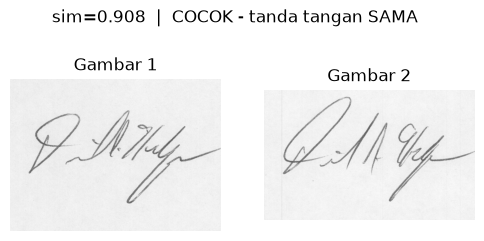

In [5]:
# --- EDIT DI SINI: dua gambar yang mau dibandingkan ---
GAMBAR_1 = r'DataSets/Cedar/full_org/original_10_1.png'    # acuan (asli)
GAMBAR_2 = r'DataSets/Cedar/full_org/original_10_5.png'    # yang dicek
THRESHOLD = 0.85

# --- diagnosa: pastikan yang dibandingkan benar-benar sesuai maksudmu ---
p1 = os.path.abspath(str(GAMBAR_1).strip().strip('"').strip(chr(39)))
p2 = os.path.abspath(str(GAMBAR_2).strip().strip('"').strip(chr(39)))
print('GAMBAR_1 :', p1, '| ADA' if os.path.isfile(p1) else '| >>> TIDAK ADA <<<')
print('GAMBAR_2 :', p2, '| ADA' if os.path.isfile(p2) else '| >>> TIDAK ADA <<<')
assert os.path.isfile(p1) and os.path.isfile(p2), 'Salah satu file tidak ditemukan — cek lagi path-nya.'
if p1 == p2:
    print('CATATAN: kedua path SAMA -> kemiripan pasti 1.00 (COCOK).')
else:
    print(f'Kedua path BEDA (size: {os.path.getsize(p1)} vs {os.path.getsize(p2)} bytes).')

sim, verdict = compare(p1, p2, THRESHOLD)
bar = '#' * int(max(0.0, min(1.0, sim)) * 40)
print('-' * 48)
print(f'Kemiripan (cosine) : {sim:.4f}')
print(f'Threshold          : {THRESHOLD:.2f}')
print(f'[{bar:<40}] {sim*100:.1f}%')
print(f'=> {verdict}')
show_pair(p1, p2, f'sim={sim:.3f}  |  {verdict}')

## 6. Langkah 1 (alternatif) — banyak gambar ACUAN (TTD asli)

Isi `REFS` dengan path gambar TTD asli. Bisa daftar file **atau** satu folder (semua gambar di dalamnya dipakai). Lalu jalankan sel untuk meng-embed acuan.

In [6]:
# --- EDIT DI SINI: path gambar acuan (file-file, atau satu folder) ---
REFS = [
    r'DataSets/Cedar/full_org/original_10_1.png',
    r'DataSets/Cedar/full_org/original_10_2.png',
    r'DataSets/Cedar/full_org/original_10_3.png',
]

IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp', '.tif', '.tiff')
def _expand(items):
    out = []
    for r in items:
        r = str(r).strip().strip('"').strip(chr(39))
        if os.path.isdir(r):
            out += [os.path.join(r, f) for f in sorted(os.listdir(r)) if f.lower().endswith(IMG_EXTS)]
        elif os.path.isfile(r) and r.lower().endswith(IMG_EXTS):
            out.append(r)
        else:
            print('  ! dilewati (tidak valid):', r)
    return out

ref_paths = _expand(REFS)
assert ref_paths, 'Tidak ada gambar acuan yang valid.'
ref_embs = embed_many(ref_paths)
print(f'{len(ref_paths)} gambar acuan siap di-embed. embedding shape = {ref_embs.shape}')

3 gambar acuan siap di-embed. embedding shape = (3, 512)


## 7. Langkah 2 — uji satu gambar (vs banyak acuan)

Set `TEST_IMAGE` ke gambar yang mau diuji lalu jalankan.

> **Penting soal threshold:** checkpoint ini menyimpan `threshold=0.96`, tapi pada uji nyata CEDAR itu **menolak hampir semua TTD asli** (asli rata-rata ~0.90). Pemisah genuine/forgery yang lebih realistis ada di **~0.83**. Karena itu `THRESHOLD_UJI` di bawah default ke 0.83 — silakan geser sesuai kebutuhan.

mean_sim  = 0.9173   (max=0.9227  min=0.9075)
threshold = 0.8300   |  acuan = 3
[####################################    ] 91.7%
=> GENUINE (asli)


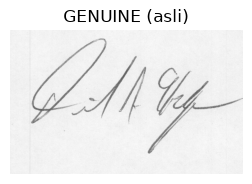

In [7]:
# --- EDIT DI SINI ---
TEST_IMAGE = r'DataSets/Cedar/full_org/original_10_5.png'   # coba ganti ke forgeries_10_1.png
THRESHOLD_UJI = 0.83    # rekomendasi (bawaan checkpoint 0.96 terlalu ketat -> tolak semua asli)

res = verify(TEST_IMAGE, ref_embs, threshold=THRESHOLD_UJI)
bar = '#' * int(max(0.0, min(1.0, res['mean_sim'])) * 40)
print(f"mean_sim  = {res['mean_sim']:.4f}   (max={res['max_sim']:.4f}  min={res['min_sim']:.4f})")
print(f"threshold = {res['threshold']:.4f}   |  acuan = {res['num_refs']}")
print(f"[{bar:<40}] {res['mean_sim']*100:.1f}%")
print('=>', res['verdict'])
show(TEST_IMAGE, res['verdict'])

## 8. (Opsional) Uji banyak gambar sekaligus

Set `TEST_BATCH` ke daftar file atau satu folder untuk melihat skor semuanya sekaligus.

In [8]:
TEST_BATCH = r'DataSets/Cedar/full_forg'   # folder atau list path

batch = _expand([TEST_BATCH] if isinstance(TEST_BATCH, str) else TEST_BATCH)[:20]
print(f"{'file':45s} {'mean_sim':>9s}  verdict")
print('-' * 70)
for p in batch:
    r = verify(p, ref_embs, threshold=THRESHOLD_UJI)
    print(f'{os.path.basename(p):45s} {r["mean_sim"]:>9.4f}  {r["verdict"]}')

file                                           mean_sim  verdict
----------------------------------------------------------------------
forgeries_10_1.png                               0.8414  GENUINE (asli)
forgeries_10_10.png                              0.5815  FORGED (palsu)
forgeries_10_11.png                              0.5538  FORGED (palsu)
forgeries_10_12.png                              0.6517  FORGED (palsu)
forgeries_10_13.png                              0.8437  GENUINE (asli)
forgeries_10_14.png                              0.6940  FORGED (palsu)
forgeries_10_15.png                              0.7136  FORGED (palsu)
forgeries_10_16.png                              0.7102  FORGED (palsu)
forgeries_10_17.png                              0.8191  FORGED (palsu)
forgeries_10_18.png                              0.7828  FORGED (palsu)
forgeries_10_19.png                              0.6917  FORGED (palsu)
forgeries_10_2.png                               0.7884  FORGED (palsu)


## 9. Upload 2 gambar dari komputer & bandingkan  ⭐

Cara paling gampang tanpa ngetik path: klik 2 tombol upload, pilih **Gambar 1** dan **Gambar 2**, atur threshold, lalu jalankan sel bawah.

Butuh `ipywidgets` (sekali saja): `pip install ipywidgets` lalu restart kernel.

In [9]:
# --- Sel A: munculkan 2 tombol upload + slider threshold ---
try:
    import ipywidgets as widgets
    from IPython.display import display
    up1 = widgets.FileUpload(accept='image/*', multiple=False, description='Gambar 1')
    up2 = widgets.FileUpload(accept='image/*', multiple=False, description='Gambar 2')
    thr_slider = widgets.FloatSlider(value=0.85, min=0.50, max=0.98, step=0.01,
                                     description='Threshold', readout_format='.2f')
    display(widgets.VBox([up1, up2, thr_slider]))
    print('Pilih 2 gambar + atur threshold di atas, lalu jalankan sel berikutnya.')
except Exception as e:
    print('ipywidgets belum terpasang:', e)
    print('Install sekali:  pip install ipywidgets   (lalu Restart Kernel)')
    print('Alternatif tanpa upload: pakai Bagian 5 (isi GAMBAR_1 & GAMBAR_2).')

Pilih 2 gambar + atur threshold di atas, lalu jalankan sel berikutnya.


Gambar 1 : 1_1_1.png
Gambar 2 : 4_1_1.png
Kemiripan (cosine) : 0.4369
Threshold          : 0.85
[#################                       ] 43.7%
=> TIDAK COCOK - tanda tangan BEDA


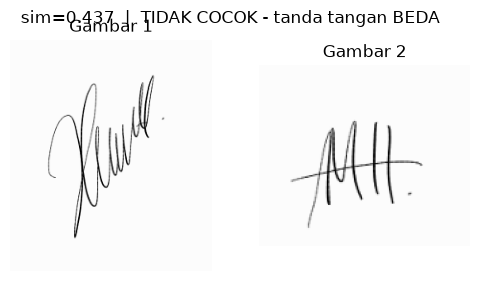

In [16]:
# --- Sel B: baca 2 upload, simpan, bandingkan ---
def _read_upload(up):
    v = getattr(up, 'value', None)
    if not v:
        return None, None
    item = list(v.values())[0] if isinstance(v, dict) else v[0]   # v7 dict / v8 tuple
    name = item.get('name') or item.get('metadata', {}).get('name') or 'upload'
    return bytes(item['content']), name

if 'up1' in dir() and 'up2' in dir():
    c1, n1 = _read_upload(up1)
    c2, n2 = _read_upload(up2)
    if not c1 or not c2:
        print('Belum ada 2 gambar. Upload GAMBAR 1 dan GAMBAR 2 di sel atas dulu.')
    else:
        f1, f2 = '_upload_1.png', '_upload_2.png'
        open(f1, 'wb').write(c1); open(f2, 'wb').write(c2)
        thr = thr_slider.value if 'thr_slider' in dir() else 0.85
        sim, verdict = compare(f1, f2, thr)
        bar = '#' * int(max(0.0, min(1.0, sim)) * 40)
        print(f'Gambar 1 : {n1}')
        print(f'Gambar 2 : {n2}')
        print(f'Kemiripan (cosine) : {sim:.4f}')
        print(f'Threshold          : {thr:.2f}')
        print(f'[{bar:<40}] {sim*100:.1f}%')
        print(f'=> {verdict}')
        show_pair(f1, f2, f'sim={sim:.3f}  |  {verdict}')
else:
    print('Jalankan sel widget (Sel A) di atas dulu.')